In [3]:
import pandas as pd

X = pd.Series([1, 2, 3, 4, 5])
Y = pd.Series([2, 4, 6, 8, 10])

X.corr(Y)

np.float64(0.9999999999999999)

In [4]:
X = pd.Series([1, 2, 3, 4, 5])
Y = pd.Series([10, 8, 6, 4, 2])

X.corr(Y)

np.float64(-0.9999999999999999)

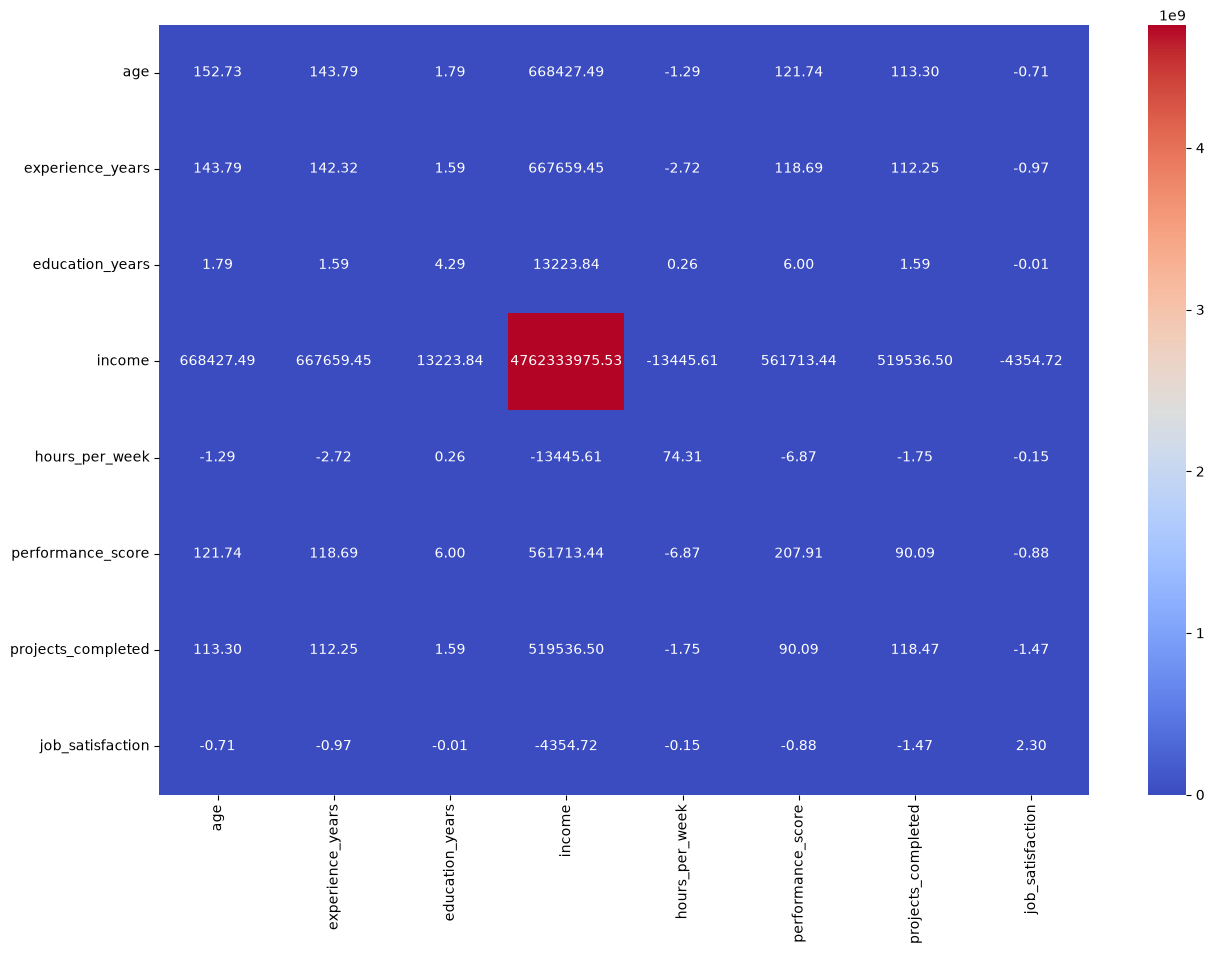

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("outliers_imputation_practice.xls")

cov_matrix = df.cov()

plt.figure(figsize=(15, 10))

sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.show()

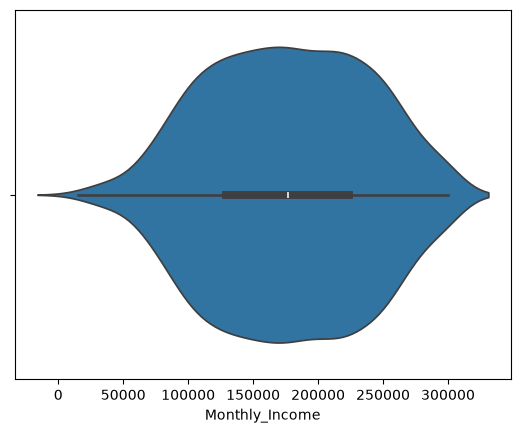

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("numerical_ml_practice_1000.csv")

sns.violinplot(x=df["Monthly_Income"])
plt.show()

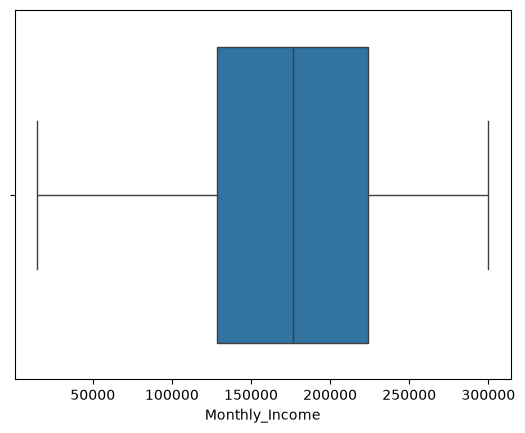

In [21]:
sns.boxplot(x=df["Monthly_Income"])
plt.show()

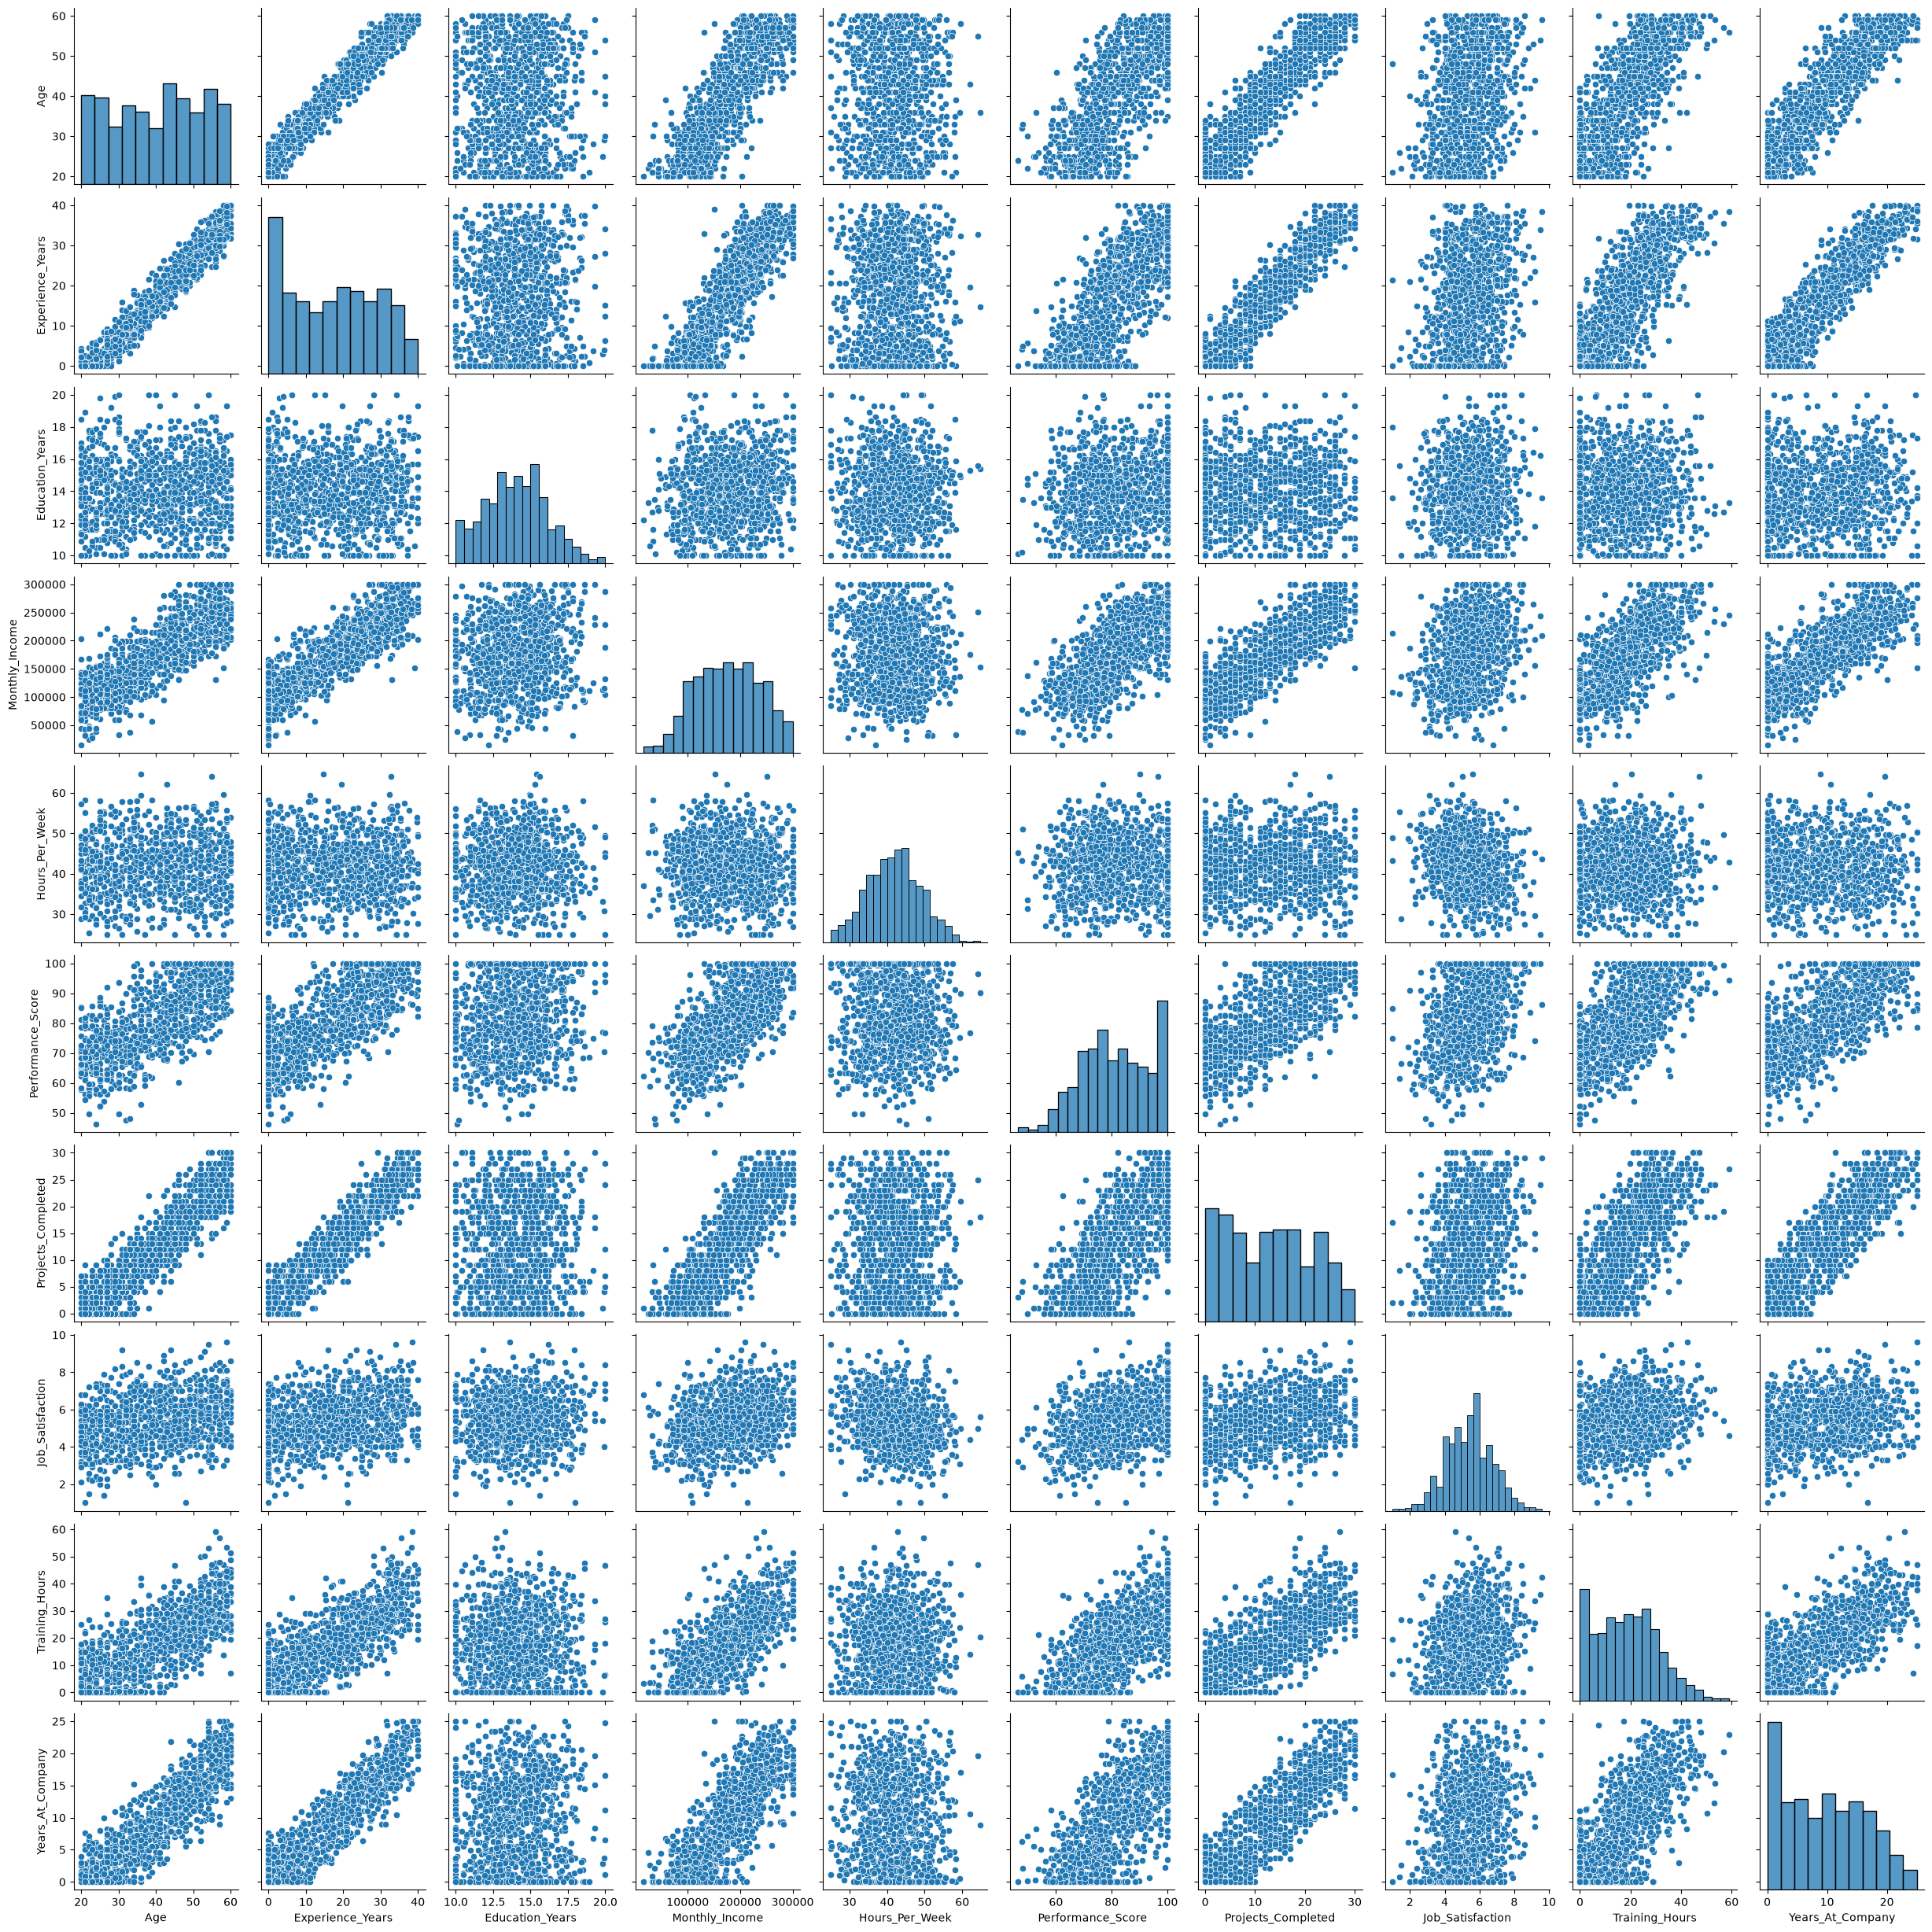

In [22]:
sns.pairplot(df)
plt.show()

In [26]:
df.cov(numeric_only=True)["Monthly_Income"]

Age                   6.133483e+05
Experience_Years      6.292357e+05
Education_Years       1.681886e+04
Monthly_Income        3.805138e+09
Hours_Per_Week       -1.439294e+03
Performance_Score     5.282791e+05
Projects_Completed    4.267736e+05
Job_Satisfaction      2.499437e+04
Training_Hours        5.122253e+05
Years_At_Company      3.303382e+05
Name: Monthly_Income, dtype: float64

In [28]:
df.skew()

Age                  -0.090236
Experience_Years      0.048088
Education_Years       0.167822
Monthly_Income       -0.044738
Hours_Per_Week        0.036044
Performance_Score    -0.119984
Projects_Completed    0.110871
Job_Satisfaction      0.005474
Training_Hours        0.285789
Years_At_Company      0.209410
dtype: float64

In [29]:
df.kurtosis()

Age                  -1.235645
Experience_Years     -1.237778
Education_Years      -0.324149
Monthly_Income       -0.766195
Hours_Per_Week       -0.290261
Performance_Score    -0.813832
Projects_Completed   -1.122531
Job_Satisfaction      0.005095
Training_Hours       -0.503278
Years_At_Company     -1.049694
dtype: float64

In [6]:
import pandas as pd

df = pd.read_csv("housing_numeric_messy.csv")

df.head()

,row_id,area_sqft,bedrooms,bathrooms,age_years,distance_to_center_km,floor_number,garage_spaces,crime_index,school_rating,local_median_income,annual_tax,listing_version,random_noise,price
0,66,1382.1,1.0,1.0,37.0,7.08,23.0,0.0,55.0,6.3,44626.0,1570.90,1.0,0.4839,157687.0
1,59,2449.1,4.0,3.0,20.0,16.55,7.0,2.0,48.8,NaN,15573.0,3609.93,1.0,0.3828,259834.0
2,3,1344.9,2.0,1.0,34.0,2.05,10.0,2.0,57.1,8.8,48493.0,2156.94,1.0,-0.3752,186014.0
3,566,871.3,2.0,1.0,37.0,13.33,23.0,2.0,37.4,5.8,NaN,1589.72,1.0,-0.3345,98975.0
4,190,0.0,2.0,1.0,23.0,7.70,24.0,2.0,46.9,NaN,54235.0,2106.64,1.0,0.3193,191416.0


In [7]:
df.isna().sum()

row_id                     0
area_sqft                 40
bedrooms                   0
bathrooms                 71
age_years                101
distance_to_center_km      0
floor_number               0
garage_spaces             50
crime_index               78
school_rating            122
local_median_income      153
annual_tax                 0
listing_version            0
random_noise               0
price                     20
dtype: int64

In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder

kimputer = KNNImputer(n_neighbors=5)

encoder = LabelEncoder()

mimputer = IterativeImputer(max_iter=5, random_state=54)

df_kimputed = pd.DataFrame(
    kimputer.fit_transform(df),
    columns=df.columns
    )

df_mimputed = pd.DataFrame(
    mimputer.fit_transform(df),
    columns=df.columns
    )

df_kimputed.head()

df_kimputed.isna().sum()

df_mimputed.head()

df_mimputed.isna().sum()

row_id                   0
area_sqft                0
bedrooms                 0
bathrooms                0
age_years                0
distance_to_center_km    0
floor_number             0
garage_spaces            0
crime_index              0
school_rating            0
local_median_income      0
annual_tax               0
listing_version          0
random_noise             0
price                    0
dtype: int64

In [2]:
import pandas as pd

df = pd.read_csv("outliers_imputation_practice.xls")

In [5]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

imputer = KNNImputer()

model = LinearRegression()

rfe = RFE(estimator=model, n_features_to_select=3)

df_imputer = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

X = df_imputer.drop(columns=["income"])
Y = df_imputer["income"]

rfe.fit(X, Y)

selectede_feature = X.columns[rfe.support_]

print(selectede_feature)

Index(['age', 'experience_years', 'education_years'], dtype='str')


In [8]:
import numpy as np
from scipy.stats import zscore

X = np.array([1, 3, 5, 100, 34, 20, 30, 35])

z_score = zscore(X)

outliers = X[np.abs(z_score) > 1]

print(outliers)

[100]


In [11]:
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)

IQR = Q3 - Q1

lower_bond = Q1 - 1.5 * IQR
upper_bond = Q3 + 1.5 * IQR

outliers = X[(X < lower_bond) | (X > upper_bond)]

print(outliers)

[100]


In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=100, random_state=10)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

display(df_imputed)

df_imputed.isna().sum()

,age,experience_years,education_years,income,hours_per_week,performance_score,projects_completed,job_satisfaction
0,56.0,34.000000,16.0,192108.58,33.0,100.000000,29.000000,7.100000
1,46.0,19.000000,12.0,115700.97,32.2,93.180000,17.000000,6.772306
2,32.0,14.000000,16.0,118094.75,37.9,89.850000,13.000000,7.520000
3,60.0,37.000000,14.0,207761.74,49.3,100.000000,31.951864,5.510000
4,25.0,2.477007,16.0,53154.85,31.4,77.662431,0.000000,10.000000
...,...,...,...,...,...,...,...,...
995,50.0,31.000000,16.0,170826.96,37.6,100.000000,24.000000,8.830000
996,21.0,0.000000,12.0,50426.91,38.6,59.190000,4.000000,8.820000
997,39.0,17.054618,12.0,120388.75,46.4,89.100000,16.000000,8.970000
998,19.0,0.000000,14.0,42263.64,42.2,90.180000,2.000000,7.240000


age                   0
experience_years      0
education_years       0
income                0
hours_per_week        0
performance_score     0
projects_completed    0
job_satisfaction      0
dtype: int64

(array([26.,  0., 26.,  0., 24.,  0.,  0., 21.,  0., 27.,  0., 22.,  0.,
         0., 14.,  0., 25.,  0.,  0., 21.,  0., 19.,  0., 23.,  0.,  0.,
        21.,  0., 19.,  0., 24.,  0.,  0., 20.,  0., 19.,  0.,  0., 24.,
         0., 16.,  0., 20.,  0.,  0., 19.,  0., 19.,  0.,  0., 24.,  0.,
        23.,  0., 23.,  0.,  0., 26.,  0., 33.,  0., 17.,  0.,  0., 29.,
         0., 22.,  0.,  0., 23.,  0., 17.,  0., 26.,  0.,  0., 36.,  0.,
        18.,  0., 32.,  0.,  0., 23.,  0., 31.,  0.,  0., 19.,  0., 28.,
         0., 23.,  0.,  0., 17.,  0., 19.,  0., 12.]),
 array([18.  , 18.42, 18.84, 19.26, 19.68, 20.1 , 20.52, 20.94, 21.36,
        21.78, 22.2 , 22.62, 23.04, 23.46, 23.88, 24.3 , 24.72, 25.14,
        25.56, 25.98, 26.4 , 26.82, 27.24, 27.66, 28.08, 28.5 , 28.92,
        29.34, 29.76, 30.18, 30.6 , 31.02, 31.44, 31.86, 32.28, 32.7 ,
        33.12, 33.54, 33.96, 34.38, 34.8 , 35.22, 35.64, 36.06, 36.48,
        36.9 , 37.32, 37.74, 38.16, 38.58, 39.  , 39.42, 39.84, 40.26,
        

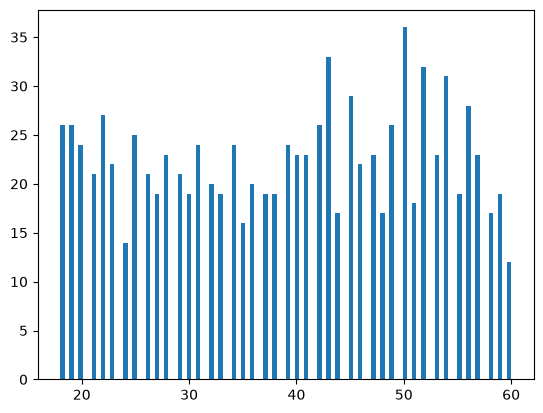

In [5]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=100)

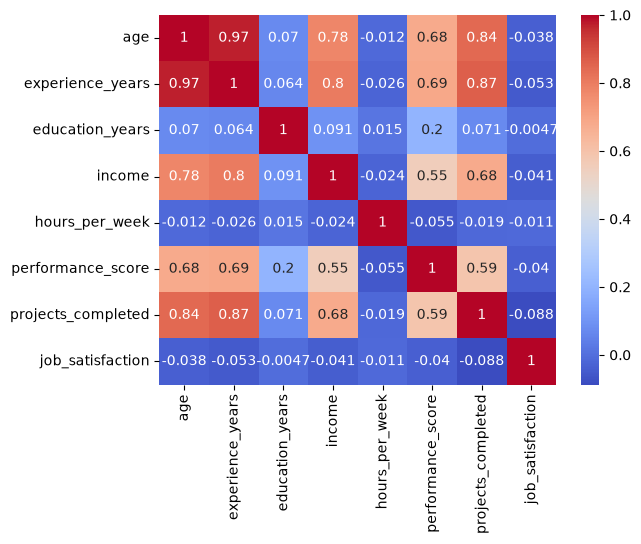

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outliers_imputation_practice.xls")

df_corr = df.corr(numeric_only=True)

sns.heatmap(df_corr, annot=True, cmap="coolwarm")
plt.show()

In [7]:
df.cov(numeric_only=True)["age"]

age                      152.730331
experience_years         143.787017
education_years            1.785090
income                668427.494052
hours_per_week            -1.286042
performance_score        121.737659
projects_completed       113.297193
job_satisfaction          -0.705353
Name: age, dtype: float64

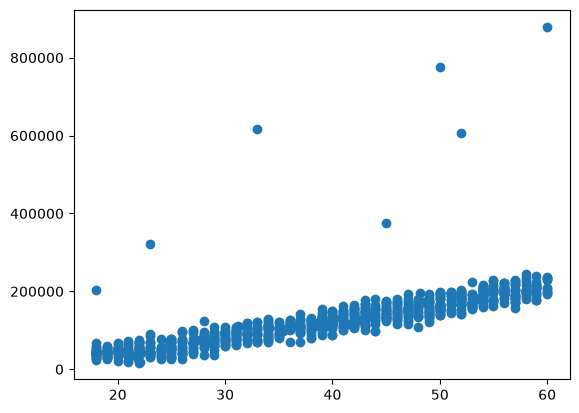

In [18]:
df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

plt.scatter(df["age"], df["income"])
plt.show()

<Axes: xlabel='income'>

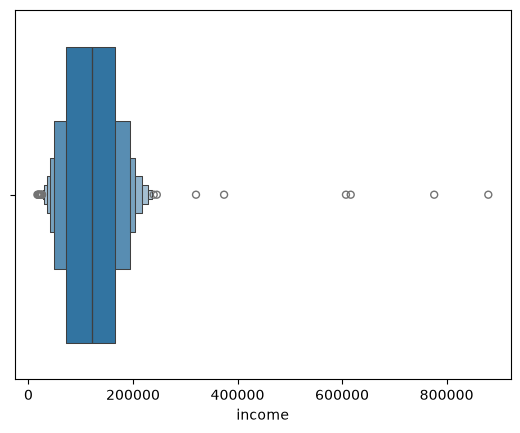

In [23]:
sns.boxenplot(x=df["income"])

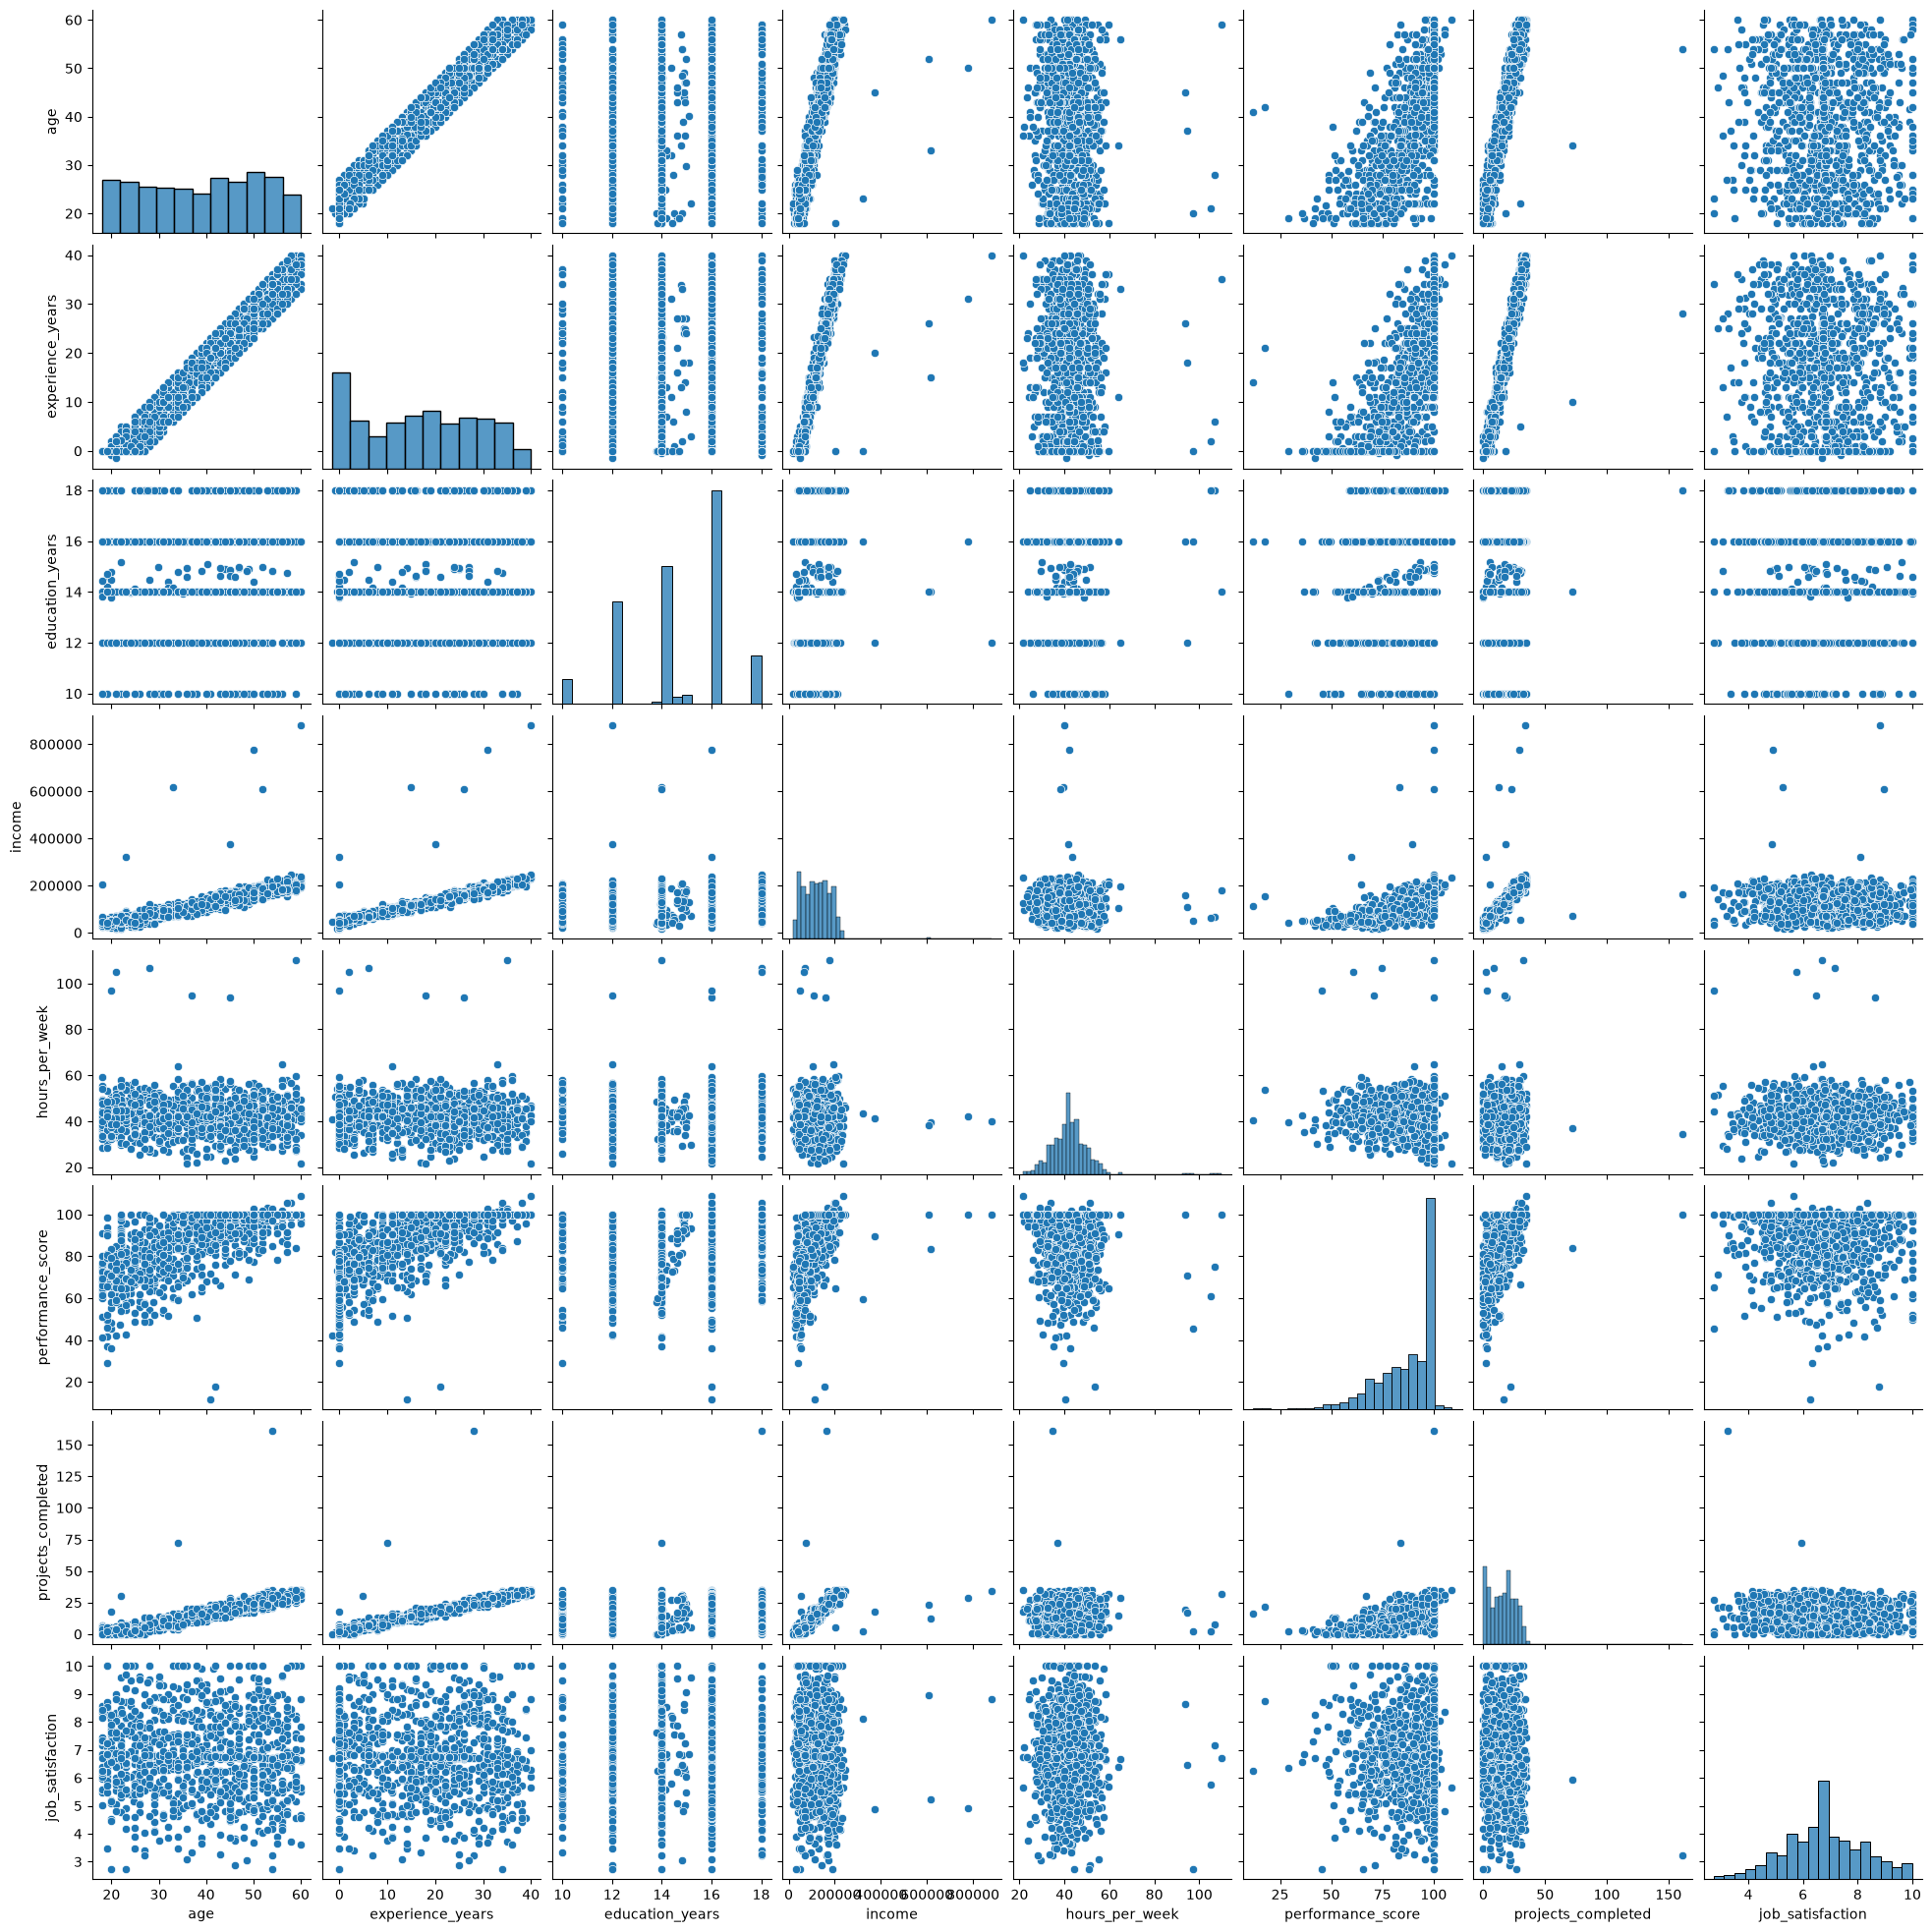

In [24]:
sns.pairplot(df)
plt.show()

<Axes: ylabel='income'>

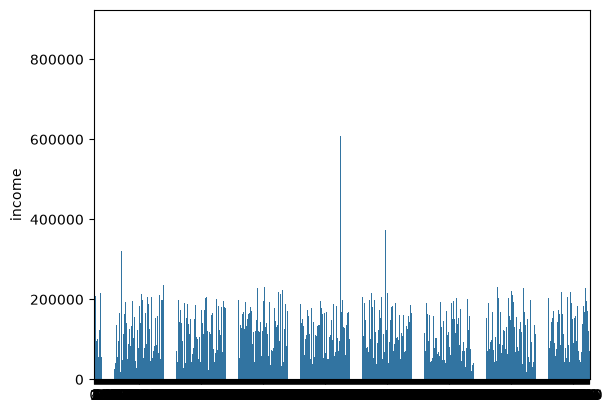

In [25]:
sns.barplot(df["income"])

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("outliers_imputation_practice.xls")

In [2]:
df.dtypes

age                   float64
experience_years      float64
education_years       float64
income                float64
hours_per_week        float64
performance_score     float64
projects_completed    float64
job_satisfaction      float64
dtype: object

In [6]:
df["age"].mean()

np.float64(39.103092783505154)

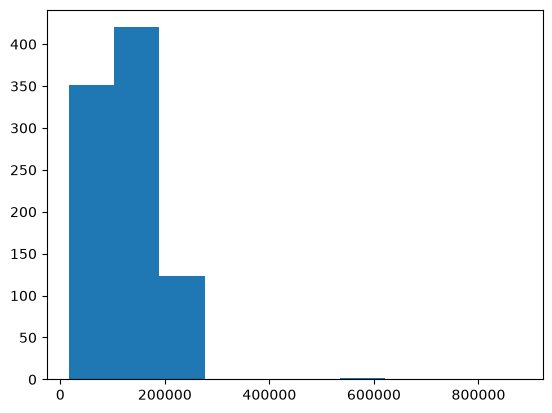

In [12]:
plt.hist(df["income"], bins=10)
plt.show()

<Axes: xlabel='age'>

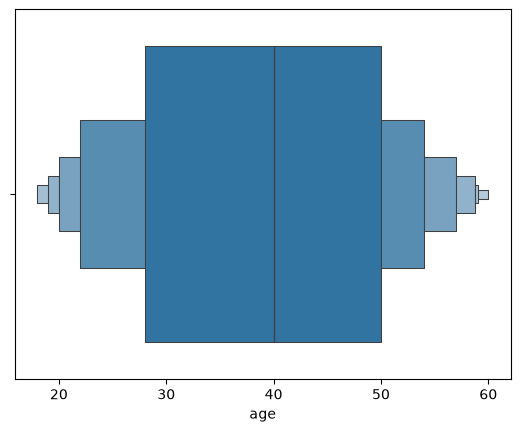

In [13]:
sns.boxenplot(x=df["age"])

<Axes: xlabel='age'>

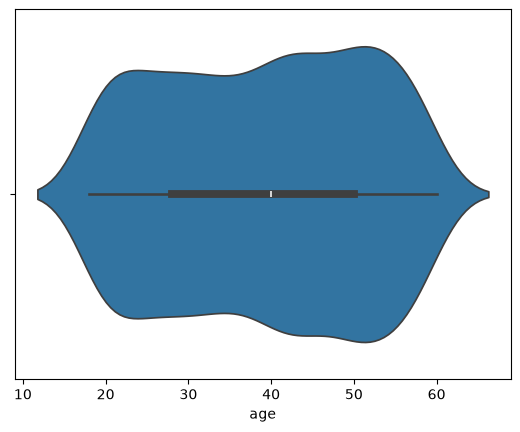

In [15]:
sns.violinplot(x=df["age"])

In [20]:
df.corr(numeric_only=True)["income"]

age                   0.777266
experience_years      0.802388
education_years       0.091330
income                1.000000
hours_per_week       -0.023975
performance_score     0.553712
projects_completed    0.680860
job_satisfaction     -0.040896
Name: income, dtype: float64

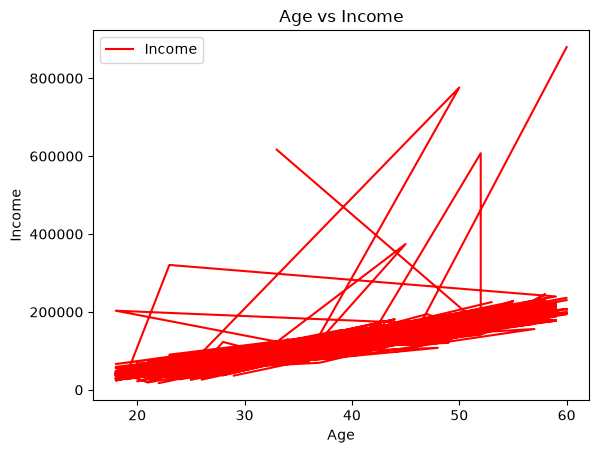

In [23]:
plt.plot(df["age"], df["income"], color="red", label="Income")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income")

plt.legend()

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10472\2207715636.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


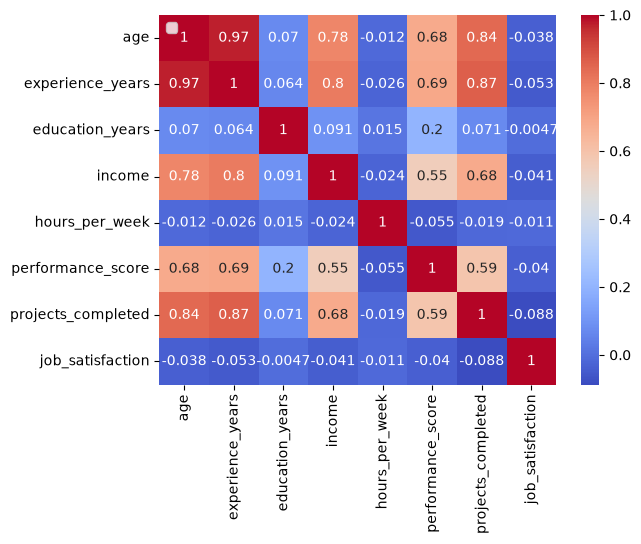

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outliers_imputation_practice.xls")

df_pearson = df.corr(method="pearson", numeric_only=True)

sns.heatmap(df_pearson, annot=True, cmap="coolwarm")

plt.show()

<Axes: >

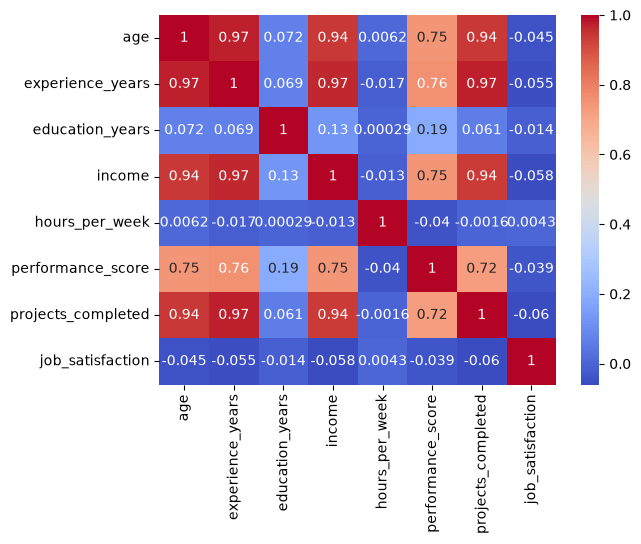

In [28]:
df_spearman = df.corr(method="spearman", numeric_only=True)

sns.heatmap(df_spearman, annot=True, cmap="coolwarm")

In [33]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()

rfe = RFE(estimator=model, n_features_to_select=3)

X = df.drop(columns=["income"])
y = df["income"]

X = X.fillna(df.median)
y = y.fillna(df.median)

rfe.fit(X, y)

selected_feature = X.columns[rfe.support_]

print(selectede_feature)

TypeError: float() argument must be a string or a real number, not 'method'

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10472\3223679460.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


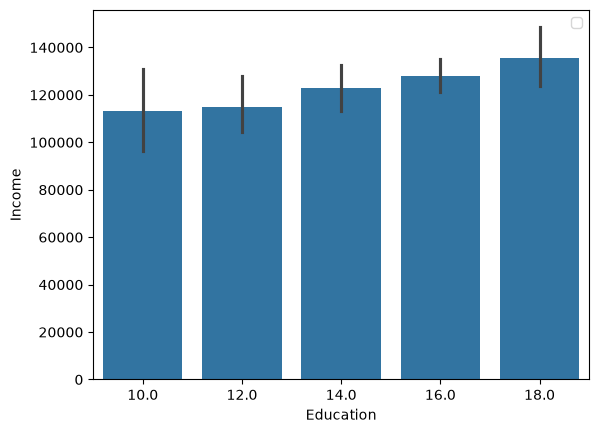

In [43]:
sns.barplot(
    data=df,
    x="education_years",
    y="income"
)

plt.xlabel("Education")
plt.ylabel("Income")

plt.legend()

plt.show()

<Axes: ylabel='income'>

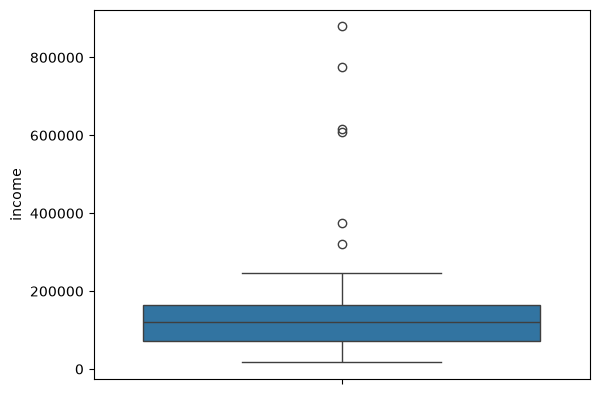

In [45]:
sns.boxplot(df["income"])